# Part 1, Task 3 - develop A* Search Algorithm with a suitable heuristic function.

For this task, we decided to use Euclidean distance as our heuristic function. This serves as an approximation for the algorithm to calculate the distance between the current node and the goal node.

we shall use f(n) = a * g(n) + b* h(n), experimenting with appropriate values for a & b to find shortest distance where g(n) is the culmulative cost from the start node to the current node, and h(n) is the heuristic cost estimate from the current node to the goal node.

In [26]:
import json
import heapq
import time
import matplotlib.pyplot as plt

with open("../data/G.json", "r") as f:
    G = json.load(f)

with open("../data/Coord.json", "r") as f:
    Coord = json.load(f)

with open("../data/Dist.json", "r") as f:
    Dist = json.load(f)

with open("../data/Cost.json", "r") as f:
    Cost = json.load(f)

with open("../data/heuristic.json", "r") as f:
    heuristic = json.load(f)


def a_star_distance(G, Cost, Dist, heuristic, start, goal, max_energy, alpha=1, beta=1):
    # (f(n), node, path, energy_used, distance_travelled)
    pq = [(0, start, [start], 0, 0)]

    visited = dict()
    nodes_expanded = 0
    explored_nodes = [] 

    while pq:
        f_n, node, path, energy_used, dist_travelled = heapq.heappop(pq)

        nodes_expanded += 1
        explored_nodes.append(node)

        if energy_used > max_energy:
            continue

        if node == goal:
            return path, dist_travelled, energy_used, nodes_expanded, explored_nodes

        if node in visited and visited[node] <= dist_travelled:
            continue

        visited[node] = dist_travelled

        for neighbor in G.get(node, []):
            edge_key = f"{node},{neighbor}"

            edge_cost = Cost.get(edge_key)
            edge_dist = Dist.get(edge_key)
            h = heuristic.get(neighbor, 0)

            new_energy = energy_used + edge_cost
            new_dist = dist_travelled + edge_dist

            f_new = alpha * new_dist + beta * h

            heapq.heappush(
                pq,
                (f_new, neighbor, path + [neighbor], new_energy, new_dist)
            )

    # No path found
    return None


alpha = 1.0
beta = 1.0

start_node = "1"
goal_node = "50"
max_energy = 287932

path, dist_travelled, energy_used, nodes_expanded, explored_nodes = a_star_distance(
    G, Cost, Dist, heuristic,
    start_node, goal_node, max_energy, alpha, beta
)

print(f"Alpha: {alpha}")
print(f"Beta: {beta}")
print(f"Distance travelled: {dist_travelled}")
print(f"Energy used: {energy_used}")

print("\nFinal path:")
print(path)

Alpha: 1.0
Beta: 1.0
Distance travelled: 150784.60722193593
Energy used: 287931

Final path:
['1', '1363', '1358', '1357', '1356', '1276', '1273', '1277', '1269', '1267', '1268', '1284', '1283', '1282', '1255', '1253', '1260', '1259', '1249', '1246', '963', '964', '962', '1002', '952', '1000', '998', '994', '995', '996', '987', '986', '979', '980', '969', '977', '989', '990', '991', '2369', '2366', '2340', '2338', '2339', '2333', '2334', '2329', '2029', '2027', '2019', '2022', '2000', '1996', '1997', '1993', '1992', '1989', '1984', '2001', '1900', '1875', '1874', '1965', '1963', '1964', '1923', '1944', '1945', '1938', '1937', '1939', '1935', '1931', '1934', '1673', '1675', '1674', '1837', '1671', '1828', '1825', '1817', '1815', '1634', '1814', '1813', '1632', '1631', '1742', '1741', '1740', '1739', '1591', '1689', '1585', '1584', '1688', '1579', '1679', '1677', '104', '5680', '5418', '5431', '5425', '5429', '5426', '5428', '5434', '5435', '5433', '5436', '5398', '5404', '5402', '5396',

In [27]:
import json
import heapq
import math
import time
import matplotlib.pyplot as plt

with open("../data/G.json", "r") as f:
    G = json.load(f)       
with open("../data/Coord.json", "r") as f:
    Coord = json.load(f)    
with open("../data/Dist.json", "r") as f:
    Dist = json.load(f)     
with open("../data/Cost.json", "r") as f:
    Cost = json.load(f)    
with open("../data/heuristic.json", "r") as f:
    heuristic = json.load(f) 
    
def a_star_distance(G, Cost, Dist, heuristic, start, goal, max_energy, alpha=1, beta=1):
    pq = [(0, start, [start], 0, 0)]  # (f(n), node, path, energy_used, distance_travelled)
    visited = dict()  
    nodes_expanded = 0

    while pq:
        f_n, node, path, energy_used, dist_travelled = heapq.heappop(pq)
        nodes_expanded += 1

        if energy_used > max_energy:
            continue

        if node == goal:
            return path, dist_travelled, energy_used, nodes_expanded

        if node in visited and visited[node] <= dist_travelled:
            continue
        visited[node] = dist_travelled

        for neighbor in G.get(node, []):
            edge_key = f"{node},{neighbor}"
            edge_cost = Cost.get(edge_key, float('inf'))        
            edge_dist = Dist.get(edge_key, float('inf'))        
            h = heuristic.get(neighbor, 0)

            new_energy = energy_used + edge_cost
            new_dist = dist_travelled + edge_dist
            f_new = alpha * new_dist + beta * h  

            heapq.heappush(pq, (f_new, neighbor, path + [neighbor], new_energy, new_dist))

    # No path found
    return None

def frange(start, stop, step):
    while start <= stop:
        yield start
        start += step

Experimenting on a & b values from 1 to 100 with increments of 5

Shortest distance travelled: 150784.60722193593
Least energy used: 287931


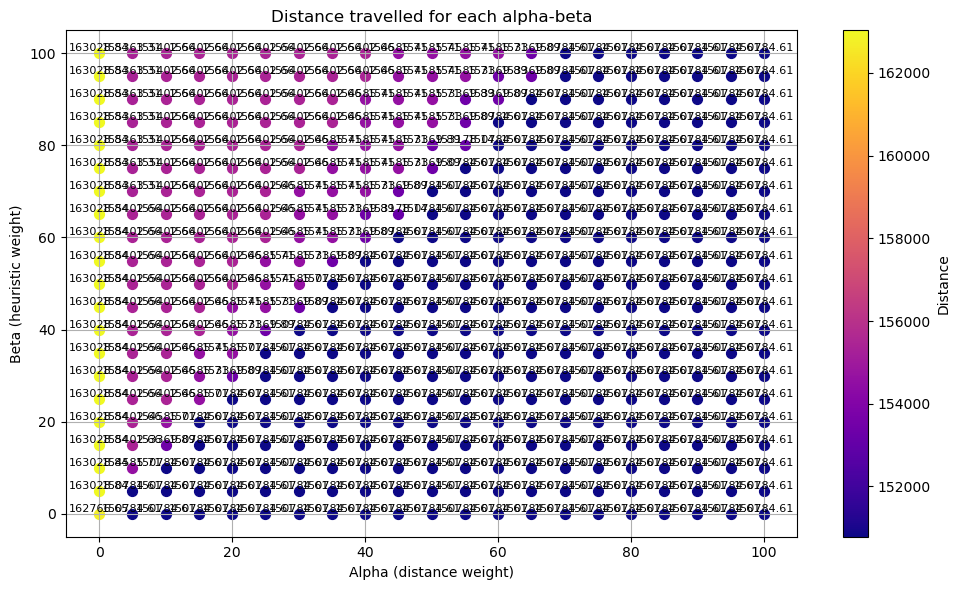

In [28]:
start_node = "1"
goal_node = "50"
max_energy = 287932

alpha_start = 0
alpha_end = 100
alpha_step = 5

beta_start = 0
beta_end = 100
beta_step = 5

alpha_values = [round(a,2) for a in frange(alpha_start, alpha_end, alpha_step)]
beta_values = [round(b,2) for b in frange(beta_start, beta_end, beta_step)]

results = []

for alpha in alpha_values:
    for beta in beta_values:
        path, dist_travelled, energy_used, nodes_expanded = a_star_distance(
            G, Cost, Dist, heuristic,
            start_node, goal_node, max_energy, alpha, beta
        )

        results.append({
            "alpha": alpha,
            "beta": beta,
            "distance_travelled": dist_travelled,
            "energy_used": energy_used,
            "nodes_expanded": nodes_expanded
        })

best_result = None

for r in results:
    if best_result is None:
        best_result = r
    else:
        if r["distance_travelled"] < best_result["distance_travelled"]:
            best_result = r

if best_result:
    print(f"Shortest distance travelled: {best_result['distance_travelled']}")
    print(f"Least energy used: {best_result['energy_used']}")

plt.figure(figsize=(10, 6))

dist_min = min(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)
dist_max = max(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)

for r in results:
    if r["distance_travelled"] is not None:
        plt.scatter(r["alpha"], r["beta"], s=50, c=r["distance_travelled"], cmap="plasma", vmin=dist_min, vmax=dist_max)
        plt.text(r["alpha"], r["beta"], f"{r['distance_travelled']:.2f}", fontsize=8, ha='center', va='bottom')
        
plt.xlabel("Alpha (distance weight)")
plt.ylabel("Beta (heuristic weight)")
plt.title("Distance travelled for each alpha-beta")
plt.colorbar(label="Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

Experimenting on a & b values from 1 to 5 with increments of 0.5

Shortest distance travelled: 150784.60722193593
Least energy used: 287931


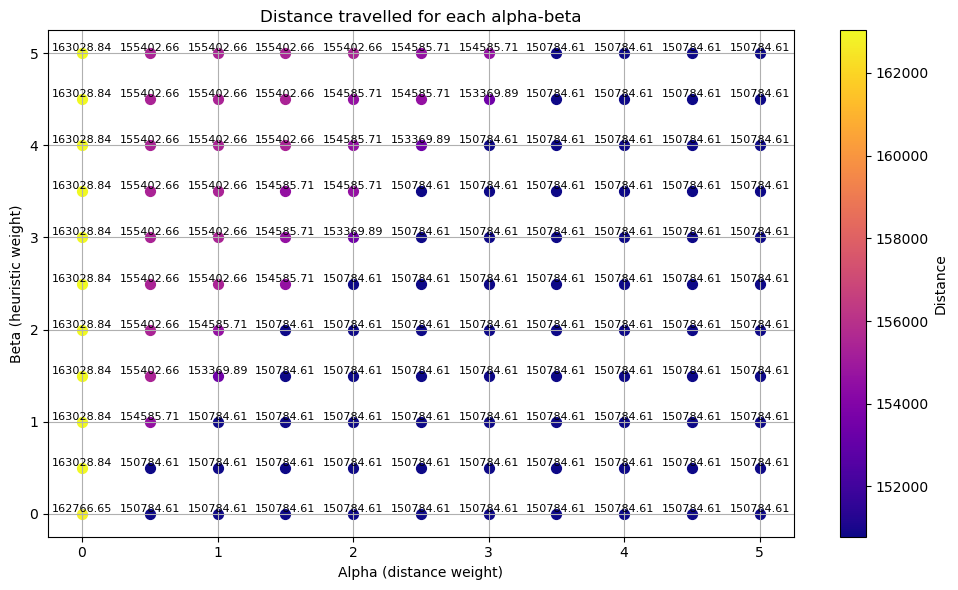

In [29]:
start_node = "1"
goal_node = "50"
max_energy = 287932

alpha_start = 0
alpha_end = 5
alpha_step = 0.5

beta_start = 0
beta_end = 5
beta_step = 0.5

alpha_values = [round(a,2) for a in frange(alpha_start, alpha_end, alpha_step)]
beta_values = [round(b,2) for b in frange(beta_start, beta_end, beta_step)]

results = []

for alpha in alpha_values:
    for beta in beta_values:
        path, dist_travelled, energy_used, nodes_expanded = a_star_distance(
            G, Cost, Dist, heuristic,
            start_node, goal_node, max_energy, alpha, beta
        )

        results.append({
            "alpha": alpha,
            "beta": beta,
            "distance_travelled": dist_travelled,
            "energy_used": energy_used,
            "nodes_expanded": nodes_expanded
        })
best_result = None

for r in results:
    if best_result is None:
        best_result = r
    else:
        if r["distance_travelled"] < best_result["distance_travelled"]:
            best_result = r

if best_result:
    print(f"Shortest distance travelled: {best_result['distance_travelled']}")
    print(f"Least energy used: {best_result['energy_used']}")

plt.figure(figsize=(10, 6))

dist_min = min(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)
dist_max = max(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)

for r in results:
    if r["distance_travelled"] is not None:
        plt.scatter(r["alpha"], r["beta"], s=50, c=r["distance_travelled"], cmap="plasma", vmin=dist_min, vmax=dist_max)
        plt.text(r["alpha"], r["beta"], f"{r['distance_travelled']:.2f}", fontsize=8, ha='center', va='bottom')

plt.xlabel("Alpha (distance weight)")
plt.ylabel("Beta (heuristic weight)")
plt.title("Distance travelled for each alpha-beta")
plt.colorbar(label="Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

experimenting on a & b values from 0 to 1 with increments of 0.1

Shortest distance travelled: 150784.61
Least energy used: 287931.00


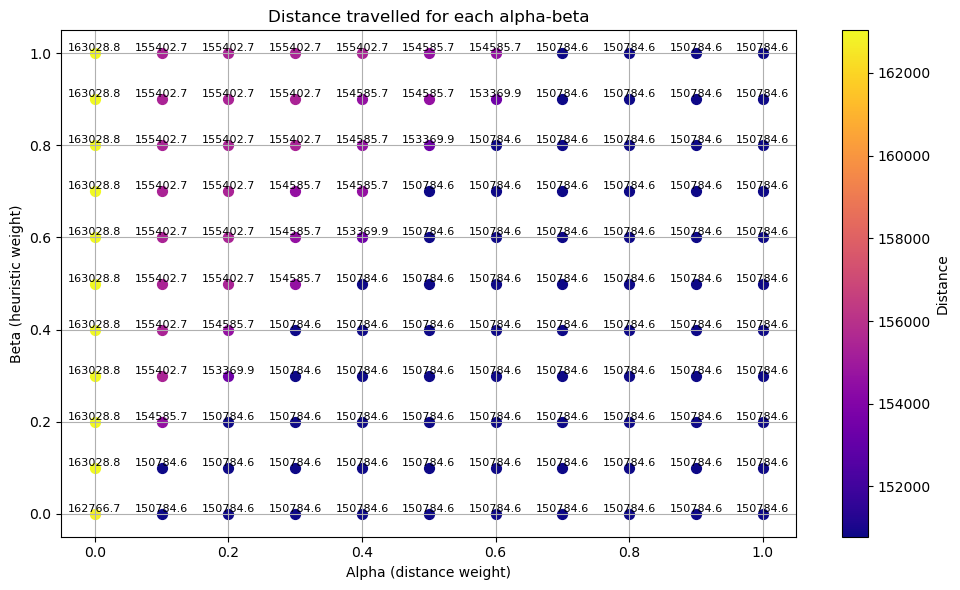

In [30]:
start_node = "1"
goal_node = "50"
max_energy = 287932

alpha_start = 0
alpha_end = 1
alpha_step = 0.1

beta_start = 0
beta_end = 1
beta_step = 0.1

alpha_values = [round(a,2) for a in frange(alpha_start, alpha_end, alpha_step)]
beta_values = [round(b,2) for b in frange(beta_start, beta_end, beta_step)]

results = []

for alpha in alpha_values:
    for beta in beta_values:
        path, dist_travelled, energy_used, nodes_expanded = a_star_distance(
            G, Cost, Dist, heuristic,
            start_node, goal_node, max_energy, alpha, beta
        )

        results.append({
            "alpha": alpha,
            "beta": beta,
            "distance_travelled": dist_travelled,
            "energy_used": energy_used,
            "nodes_expanded": nodes_expanded
        })
best_result = None

for r in results:
    if best_result is None:
        best_result = r
    else:
        if r["distance_travelled"] < best_result["distance_travelled"]:
            best_result = r

if best_result:
    print(f"Shortest distance travelled: {best_result['distance_travelled']:.2f}")
    print(f"Least energy used: {best_result['energy_used']:.2f}")

plt.figure(figsize=(10, 6))

dist_min = min(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)
dist_max = max(r["distance_travelled"] for r in results if r["distance_travelled"] is not None)

for r in results:
    if r["distance_travelled"] is not None:
        plt.scatter(r["alpha"], r["beta"], s=50, c=r["distance_travelled"], cmap="plasma", vmin=dist_min, vmax=dist_max)
        plt.text(r["alpha"], r["beta"], f"{r['distance_travelled']:.1f}", fontsize=8, ha='center', va='bottom')

plt.xlabel("Alpha (distance weight)")
plt.ylabel("Beta (heuristic weight)")
plt.title("Distance travelled for each alpha-beta")
plt.colorbar(label="Distance")
plt.grid(True)
plt.tight_layout()
plt.show()